# Health Equity & Algorithmic Fairness Analysis

**Health Analytics Society — Stroke Prevention Demo**

This notebook evaluates whether the baseline stroke risk model performs **equally across racial/ethnic groups and insurance status**. We compute stratified metrics and false negative rates (FNR) — the rate at which the model *misses* real stroke cases — because disparate FNRs are the most clinically dangerous form of model bias.

---

### Questions we're answering
1. Does AUC differ meaningfully across racial/ethnic subgroups?
2. Are false negative rates (missed strokes) higher for Black, Hispanic, or Other populations?
3. Does insurance status predict worse model performance — are uninsured patients more likely to be missed?
4. What do precision and recall look like by subgroup at our operating threshold (0.30)?

### Data context
Source: NHANES-derived dataset with 4,603 observations.
Race codes: `1=Mexican American, 2=Other Hispanic, 3=Non-Hispanic White, 4=Non-Hispanic Black, 5=Other/Multiracial`
Insurance: `1=Insured, 2=Uninsured`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path('../../')
DATA_PATH = ROOT / 'data/raw/stroke_data.csv'
THRESHOLD = 0.30
RANDOM_STATE = 42

print('Libraries loaded.')
print(f'Data path: {DATA_PATH.resolve()}')

Libraries loaded.
Data path: /Users/darylokeke/Desktop/has_projects/stroke-prevention-demo/data/raw/stroke_data.csv


## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ['General health condition', 'depression', 'Minutes sedentary activity']
TARGET_COL = 'stroke'

CODED_CATEGORICAL_COLS = [
    'gender', 'age', 'Race', 'Marital status', 'alcohol ', 'smoke',
    'sleep disorder', 'Health Insurance', 'diabetes', 'hypertension',
    'high cholesterol', 'Coronary Heart Disease', 'Body Mass Index',
]

drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]
df_clean = df.drop(columns=drop_cols)

y = df_clean[TARGET_COL]
X = df_clean.drop(columns=[TARGET_COL])

cat_cols = [c for c in CODED_CATEGORICAL_COLS if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f'Dataset shape: {df.shape}')
print(f'Stroke prevalence: {y.mean():.2%}')
print()

# Label maps for display
RACE_MAP = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    5: 'Other/Multiracial',
}
INSURANCE_MAP = {1: 'Insured', 2: 'Uninsured'}

print('Race distribution:')
race_counts = df_clean['Race'].value_counts().sort_index()
for code, count in race_counts.items():
    pct = count / len(df_clean) * 100
    print(f'  {RACE_MAP[code]}: n={count} ({pct:.1f}%)')

print()
print('Insurance distribution:')
ins_counts = df_clean['Health Insurance'].value_counts().sort_index()
for code, count in ins_counts.items():
    pct = count / len(df_clean) * 100
    print(f'  {INSURANCE_MAP[code]}: n={count} ({pct:.1f}%)')

Dataset shape: (4603, 36)
Stroke prevalence: 7.86%

Race distribution:
  Mexican American: n=518 (11.3%)
  Other Hispanic: n=447 (9.7%)
  Non-Hispanic White: n=2192 (47.6%)
  Non-Hispanic Black: n=1101 (23.9%)
  Other/Multiracial: n=345 (7.5%)

Insurance distribution:
  Insured: n=4010 (87.1%)
  Uninsured: n=593 (12.9%)


## 2. Retrain the Baseline Pipeline

We retrain from scratch (rather than loading the saved `.joblib`) to ensure sklearn version compatibility and to retain the race/insurance columns in the test set for stratified evaluation.

In [3]:
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe),
])
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
preprocess = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe, num_cols),
])
model = LogisticRegression(
    max_iter=2000, solver='liblinear',
    class_weight='balanced', C=0.1, random_state=RANDOM_STATE
)
pipeline = Pipeline([('preprocess', preprocess), ('model', model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

pipeline.fit(X_train, y_train)
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

overall_auc = roc_auc_score(y_test, y_prob)
overall_recall = recall_score(y_test, y_pred, zero_division=0)
overall_precision = precision_score(y_test, y_pred, zero_division=0)

print(f'Overall AUC:       {overall_auc:.3f}')
print(f'Overall Recall:    {overall_recall:.3f}')
print(f'Overall Precision: {overall_precision:.3f}')
print(f'Overall FNR:       {1 - overall_recall:.3f}')
print(f'Test set size:     {len(y_test)}')
print(f'Strokes in test:   {y_test.sum()}')

Overall AUC:       0.611
Overall Recall:    0.861
Overall Precision: 0.101
Overall FNR:       0.139
Test set size:     921
Strokes in test:   72


## 3. Stratified Evaluation by Race/Ethnicity

In [4]:
# Attach predictions back to test rows (keeping race/insurance for filtering)
test_df = X_test.copy()
test_df['_y_true'] = y_test.values
test_df['_y_prob'] = y_prob
test_df['_y_pred'] = y_pred


def subgroup_metrics(subset, label):
    """Compute key fairness metrics for a subgroup subset."""
    yt = subset['_y_true']
    yp_prob = subset['_y_prob']
    yp_pred = subset['_y_pred']
    n = len(yt)
    n_stroke = yt.sum()

    if n_stroke == 0 or n_stroke == n:
        return {'subgroup': label, 'n': n, 'n_stroke': int(n_stroke),
                'stroke_rate': float(n_stroke / n),
                'auc': None, 'recall': None, 'precision': None,
                'fnr': None, 'fpr': None}

    auc = roc_auc_score(yt, yp_prob)
    recall = recall_score(yt, yp_pred, zero_division=0)
    precision = precision_score(yt, yp_pred, zero_division=0)
    cm = confusion_matrix(yt, yp_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else None   # missed stroke rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else None   # false alarm rate

    return {
        'subgroup': label,
        'n': n,
        'n_stroke': int(n_stroke),
        'stroke_rate': float(n_stroke / n),
        'auc': round(auc, 3),
        'recall': round(recall, 3),
        'precision': round(precision, 3),
        'fnr': round(fnr, 3),
        'fpr': round(fpr, 3),
    }


race_results = []
for code in sorted(RACE_MAP.keys()):
    subset = test_df[test_df['Race'] == code]
    if len(subset) < 10:
        continue
    race_results.append(subgroup_metrics(subset, RACE_MAP[code]))

race_df = pd.DataFrame(race_results)
print('=== Stratified Metrics by Race/Ethnicity ===')
print(race_df.to_string(index=False))

=== Stratified Metrics by Race/Ethnicity ===
          subgroup   n  n_stroke  stroke_rate   auc  recall  precision   fnr   fpr
  Mexican American 105         9     0.085714 0.544   0.667      0.107 0.333 0.521
    Other Hispanic 101         3     0.029703 0.381   0.333      0.018 0.667 0.551
Non-Hispanic White 467        44     0.094218 0.611   0.932      0.121 0.068 0.702
Non-Hispanic Black 199        12     0.060302 0.585   0.833      0.073 0.167 0.679
 Other/Multiracial  49         4     0.081633 0.856   1.000      0.138 0.000 0.556


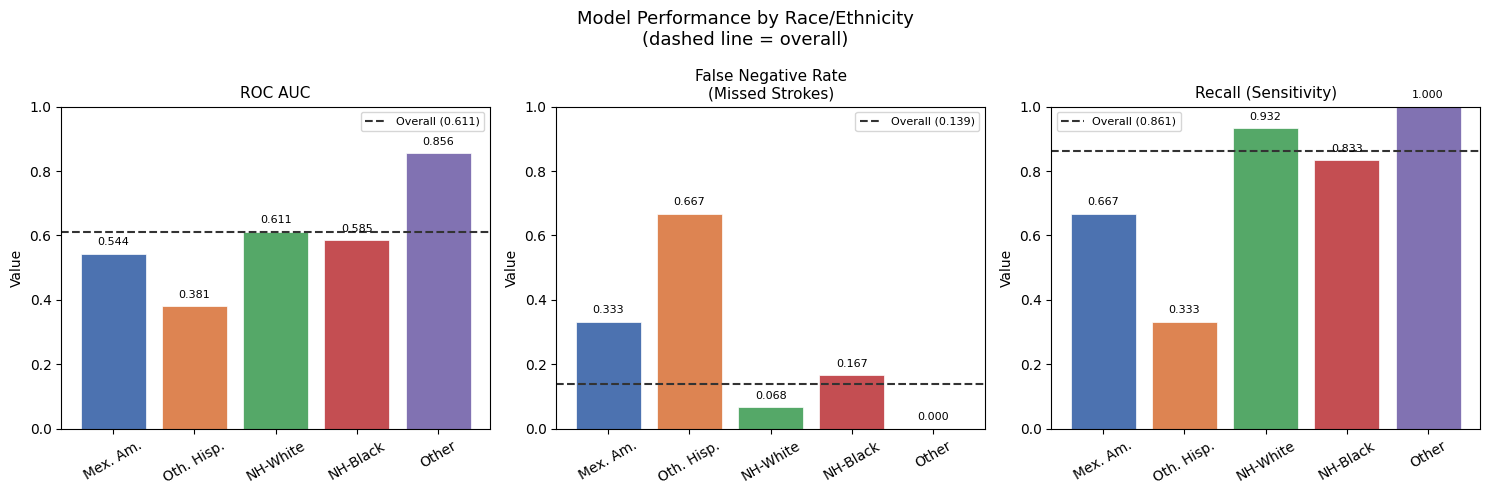

Saved: race_stratified_metrics.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance by Race/Ethnicity\n(dashed line = overall)', fontsize=13)

valid = race_df.dropna(subset=['auc', 'fnr', 'recall'])
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
bar_colors = colors[:len(valid)]

short_labels = [
    s.replace('Non-Hispanic ', 'NH-').replace('Mexican American', 'Mex. Am.').replace('Other Hispanic', 'Oth. Hisp.').replace('Other/Multiracial', 'Other')
    for s in valid['subgroup']
]

for ax, metric, label, overall_val in [
    (axes[0], 'auc', 'ROC AUC', overall_auc),
    (axes[1], 'fnr', 'False Negative Rate\n(Missed Strokes)', 1 - overall_recall),
    (axes[2], 'recall', 'Recall (Sensitivity)', overall_recall),
]:
    bars = ax.bar(short_labels, valid[metric], color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(overall_val, color='#333', linestyle='--', linewidth=1.5, label=f'Overall ({overall_val:.3f})')
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylabel('Value')
    for bar, val in zip(bars, valid[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('race_stratified_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: race_stratified_metrics.png')

## 4. Stratified Evaluation by Insurance Status

**Clinical framing:** Uninsured patients already face structural barriers to care. If the model also has a higher false negative rate for them, it compounds existing disparity — the tool would be least reliable for those who can least afford a missed diagnosis.

In [6]:
ins_results = []
for code, label in INSURANCE_MAP.items():
    subset = test_df[test_df['Health Insurance'] == code]
    ins_results.append(subgroup_metrics(subset, label))

ins_df = pd.DataFrame(ins_results)
print('=== Stratified Metrics by Insurance Status ===')
print(ins_df.to_string(index=False))

print()
insured = ins_df[ins_df['subgroup'] == 'Insured'].iloc[0]
uninsured = ins_df[ins_df['subgroup'] == 'Uninsured'].iloc[0]
if insured['fnr'] and uninsured['fnr']:
    delta = uninsured['fnr'] - insured['fnr']
    print(f'FNR gap (Uninsured - Insured): {delta:+.3f}')
    if delta > 0:
        print('⚠  Uninsured patients have a HIGHER missed-stroke rate.')
    else:
        print('✓  No FNR disparity by insurance status at this threshold.')

=== Stratified Metrics by Insurance Status ===
 subgroup   n  n_stroke  stroke_rate   auc  recall  precision   fnr   fpr
  Insured 801        65     0.081149 0.610   0.908      0.105 0.092 0.683
Uninsured 120         7     0.058333 0.507   0.429      0.057 0.571 0.442

FNR gap (Uninsured - Insured): +0.479
⚠  Uninsured patients have a HIGHER missed-stroke rate.


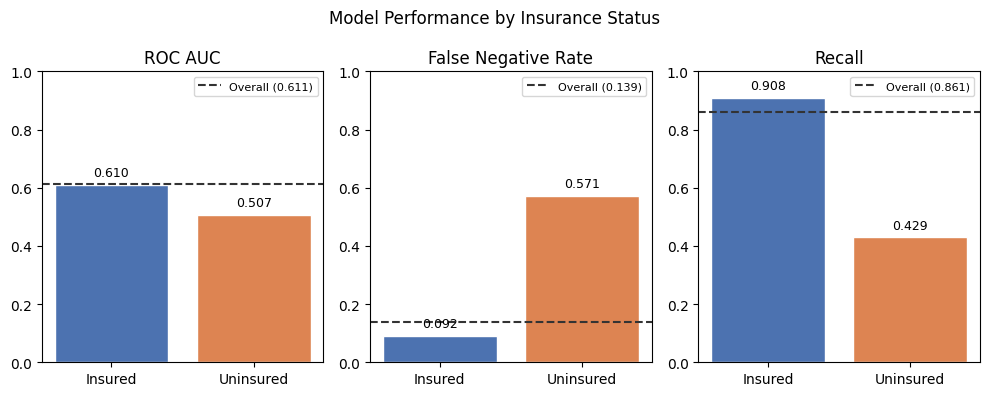

Saved: insurance_stratified_metrics.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
fig.suptitle('Model Performance by Insurance Status', fontsize=12)

ins_colors = ['#4C72B0', '#DD8452']
valid_ins = ins_df.dropna(subset=['auc', 'fnr', 'recall'])

for ax, metric, label, overall_val in [
    (axes[0], 'auc', 'ROC AUC', overall_auc),
    (axes[1], 'fnr', 'False Negative Rate', 1 - overall_recall),
    (axes[2], 'recall', 'Recall', overall_recall),
]:
    bars = ax.bar(valid_ins['subgroup'], valid_ins[metric], color=ins_colors, edgecolor='white')
    ax.axhline(overall_val, color='#333', linestyle='--', linewidth=1.5, label=f'Overall ({overall_val:.3f})')
    ax.set_title(label)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, valid_ins[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('insurance_stratified_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: insurance_stratified_metrics.png')

## 5. Intersectional Analysis: Race × Insurance

In [8]:
intersect_results = []
for race_code, race_label in RACE_MAP.items():
    for ins_code, ins_label in INSURANCE_MAP.items():
        subset = test_df[(test_df['Race'] == race_code) & (test_df['Health Insurance'] == ins_code)]
        if len(subset) < 8 or subset['_y_true'].sum() < 3:
            continue
        metrics = subgroup_metrics(subset, f'{race_label} / {ins_label}')
        metrics['race'] = race_label
        metrics['insurance'] = ins_label
        intersect_results.append(metrics)

intersect_df = pd.DataFrame(intersect_results)
print('=== Intersectional Analysis (Race × Insurance) ===')
display_cols = ['race', 'insurance', 'n', 'n_stroke', 'stroke_rate', 'auc', 'fnr', 'recall']
available_cols = [c for c in display_cols if c in intersect_df.columns]
print(intersect_df[available_cols].to_string(index=False))

=== Intersectional Analysis (Race × Insurance) ===
              race insurance   n  n_stroke  stroke_rate   auc   fnr  recall
  Mexican American   Insured  77         4     0.051948 0.729 0.000   1.000
  Mexican American Uninsured  28         5     0.178571 0.522 0.600   0.400
    Other Hispanic   Insured  89         3     0.033708 0.341 0.667   0.333
Non-Hispanic White   Insured 423        43     0.101655 0.595 0.047   0.953
Non-Hispanic Black   Insured 168        11     0.065476 0.533 0.182   0.818
 Other/Multiracial   Insured  44         4     0.090909 0.856 0.000   1.000


## 6. Score Distribution by Subgroup

Even if AUC is similar, differences in score distribution can mean the threshold (0.30) is implicitly more or less lenient for different groups. This heatmap shows how risk scores are distributed across race groups.

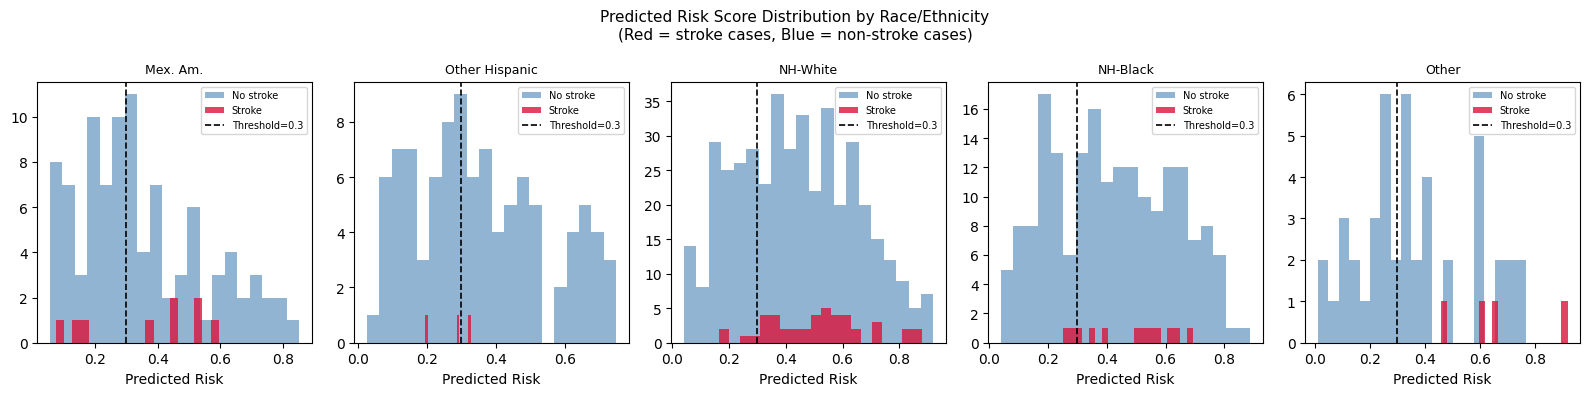

Saved: score_distribution_by_race.png


In [9]:
fig, axes = plt.subplots(1, len(RACE_MAP), figsize=(16, 4), sharey=False)
fig.suptitle('Predicted Risk Score Distribution by Race/Ethnicity\n(Red = stroke cases, Blue = non-stroke cases)', fontsize=11)

for ax, (code, label) in zip(axes, RACE_MAP.items()):
    subset = test_df[test_df['Race'] == code]
    if len(subset) == 0:
        ax.set_visible(False)
        continue

    no_stroke = subset[subset['_y_true'] == 0]['_y_prob']
    stroke = subset[subset['_y_true'] == 1]['_y_prob']

    ax.hist(no_stroke, bins=20, alpha=0.6, color='steelblue', label='No stroke')
    ax.hist(stroke, bins=20, alpha=0.8, color='crimson', label='Stroke')
    ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold={THRESHOLD}')
    short = label.replace('Non-Hispanic ', 'NH-').replace('Mexican American', 'Mex. Am.').replace('Other/Multiracial', 'Other')
    ax.set_title(short, fontsize=9)
    ax.set_xlabel('Predicted Risk')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('score_distribution_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: score_distribution_by_race.png')

## 7. Summary Table & Key Takeaways

In [10]:
print('=' * 60)
print('HEALTH EQUITY SUMMARY')
print('=' * 60)

print(f'\nOverall model: AUC={overall_auc:.3f} | FNR={1-overall_recall:.3f} | Recall={overall_recall:.3f}')

print('\n--- By Race/Ethnicity ---')
for _, row in race_df.iterrows():
    if row['auc'] is None:
        continue
    flag = '⚠' if (row['fnr'] is not None and row['fnr'] > (1 - overall_recall) + 0.05) else ' '
    print(f"  {flag} {row['subgroup']:<22} | n={row['n']:>4} | AUC={row['auc']:.3f} | FNR={row['fnr']:.3f} | Recall={row['recall']:.3f}")

print('\n--- By Insurance Status ---')
for _, row in ins_df.iterrows():
    if row['auc'] is None:
        continue
    flag = '⚠' if (row['fnr'] is not None and row['fnr'] > (1 - overall_recall) + 0.05) else ' '
    print(f"  {flag} {row['subgroup']:<22} | n={row['n']:>4} | AUC={row['auc']:.3f} | FNR={row['fnr']:.3f} | Recall={row['recall']:.3f}")

print('\n⚠ = FNR more than 5pp above overall (clinically meaningful disparity)')

print('\n--- Biggest FNR gaps vs. overall ---')
all_results = pd.concat([race_df, ins_df]).dropna(subset=['fnr'])
all_results['fnr_gap'] = all_results['fnr'] - (1 - overall_recall)
worst = all_results.nlargest(3, 'fnr_gap')[['subgroup', 'fnr', 'fnr_gap', 'n']]
print(worst.to_string(index=False))

HEALTH EQUITY SUMMARY

Overall model: AUC=0.611 | FNR=0.139 | Recall=0.861

--- By Race/Ethnicity ---
  ⚠ Mexican American       | n= 105 | AUC=0.544 | FNR=0.333 | Recall=0.667
  ⚠ Other Hispanic         | n= 101 | AUC=0.381 | FNR=0.667 | Recall=0.333
    Non-Hispanic White     | n= 467 | AUC=0.611 | FNR=0.068 | Recall=0.932
    Non-Hispanic Black     | n= 199 | AUC=0.585 | FNR=0.167 | Recall=0.833
    Other/Multiracial      | n=  49 | AUC=0.856 | FNR=0.000 | Recall=1.000

--- By Insurance Status ---
    Insured                | n= 801 | AUC=0.610 | FNR=0.092 | Recall=0.908
  ⚠ Uninsured              | n= 120 | AUC=0.507 | FNR=0.571 | Recall=0.429

⚠ = FNR more than 5pp above overall (clinically meaningful disparity)

--- Biggest FNR gaps vs. overall ---
        subgroup   fnr  fnr_gap   n
  Other Hispanic 0.667 0.528111 101
       Uninsured 0.571 0.432111 120
Mexican American 0.333 0.194111 105


---
## Interpretation Guide

**What to write up in findings.md:**

1. **AUC disparity**: If AUC varies >0.05 across groups, the model's discriminative ability is unequal. Note which groups have lower AUC and what that implies clinically.

2. **False Negative Rate (FNR)**: This is the rate at which real stroke cases are *missed*. A higher FNR for a group means those patients are more likely to be told "low risk" when they actually had a stroke. In clinical use, this is the most dangerous type of error.

3. **Why this happens**: Possible causes include:
   - Underrepresentation in training data (model learned less about that group)
   - Different clinical presentations of stroke risk across populations
   - Correlated features that proxy for race in ways that disadvantage certain groups

4. **What it means for the demo**: Even a model with decent overall AUC can perpetuate disparities. If deployed in a clinic, unequal FNRs would mean more missed strokes in already-vulnerable populations.

5. **Possible mitigations**: Reweighting by subgroup during training, threshold optimization per-group, or using fairness-aware algorithms (e.g., `fairlearn`).